# Lab 4: Phần 1 - Giảm chiều và trực quan hóa Vector

_Môi trường: Google Colab_

**Phần code vẽ có sự hỗ trợ của `ChatGPT`**

In [16]:
!pip install gensim

In [17]:
import gensim.downloader as api

print("Initializing WordEmbedder with 'glove-wiki-gigaword-300'...")
model = api.load("glove-wiki-gigaword-300")
print("Model loaded successfully.")

Initializing WordEmbedder with 'glove-wiki-gigaword-300'...
Model loaded successfully.


In [26]:
# Do bộ dữ liệu quá lớn nên trong lần thử đầu tiên với PCA, ta sẽ chọn 500 từ đầu tiên của bộ dữ liệu để trực quan
vectors = [model[word] for word in words]

In [27]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

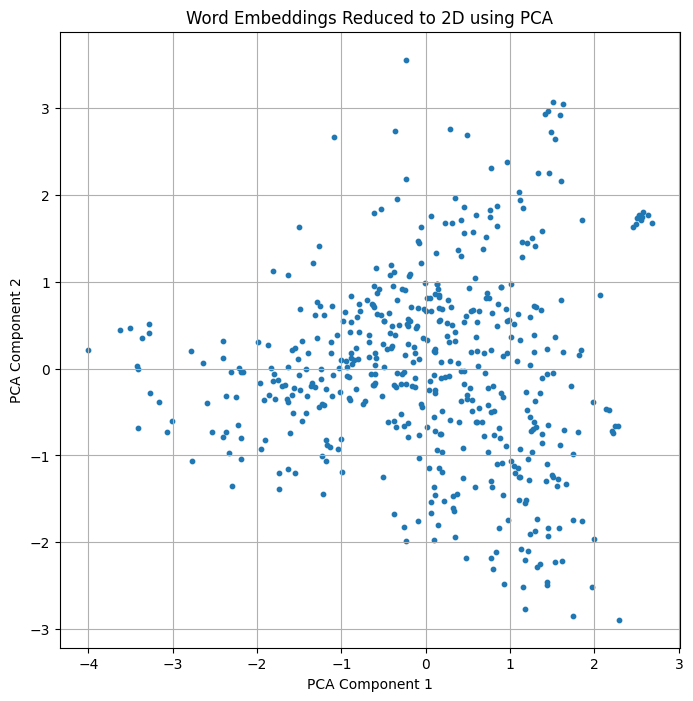

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(vectors_2d, columns=['x', 'y'])
df['word'] = words

plt.figure(figsize=(8, 8))
plt.scatter(df['x'], df['y'], s=10)

plt.title('Word Embeddings Reduced to 2D using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

**Tiếp theo thử visual 500 từ gần nghĩa với "orange" và đánh dấu 10 từ gần nghĩa nhất**

In [29]:
similar_words = model.most_similar(positive=['orange'], topn=499)
words_orange_500 = [word for word, _ in similar_words]
words_orange_500.insert(0, 'orange')

print("Hoàn thành")

Hoàn thành


In [30]:
vectors_orange_500 = [model[word] for word in words_orange_500]

In [31]:
vectors_orange_2d = pca.fit_transform(vectors_orange_500)

In [36]:
import pandas as pd
df_orange = pd.DataFrame(vectors_orange_2d, columns=['x', 'y'])
df_orange['word'] = words_orange_500
is_top_10 = [False] * len(words_orange_500)
is_top_10[1:11] = [True] * 10
df_orange['is_top_10'] = is_top_10
display(df_orange.head(10))

,x,y,word,is_top_10
0,0.299214,-0.158867,orange,False
1,1.443796,1.398971,yellow,True
2,1.188491,1.895020,colored,True
3,1.477741,1.220551,bright,True
4,1.080797,1.906507,pink,True
5,2.287293,0.764363,blue,True
6,1.399764,0.365016,red,True
7,-2.544542,-1.392414,citrus,True
8,1.196876,-0.141157,green,True
9,-3.896381,-0.647996,juice,True


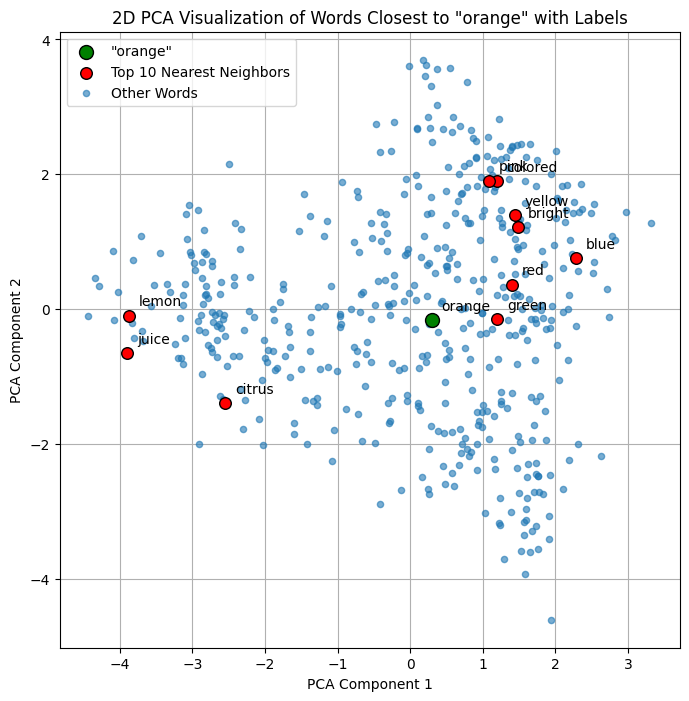

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

orange_row = df_orange[df_orange['word'] == 'orange']
plt.scatter(orange_row['x'], orange_row['y'], s=100, color='green', label='"orange"', edgecolors='black', zorder=5)

top_10_neighbors = df_orange[(df_orange['is_top_10'] == True) & (df_orange['word'] != 'orange')]
plt.scatter(top_10_neighbors['x'], top_10_neighbors['y'],
            s=70, color='red', label='Top 10 Nearest Neighbors', edgecolors='black', zorder=4)

other_words = df_orange[(df_orange['is_top_10'] == False) & (df_orange['word'] != 'orange')]
plt.scatter(other_words['x'],
            other_words['y'],
            s=20, label='Other Words', alpha=0.6, zorder=3)

for index, row in df_orange.iterrows():
    if row['word'] == 'orange' or row['is_top_10']:
        plt.annotate(row['word'], (row['x'], row['y']), textcoords="offset points", xytext=(7,7), ha='left')


plt.title('2D PCA Visualization of Words Closest to "orange" with Labels')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()